# Credit Card Fraud Detection — Exploratory Data Analysis
Explore the dataset, check class imbalance, and visualize fraud patterns.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
from pathlib import Path

%matplotlib inline
sns.set_theme(style='whitegrid')

DATA_DIR = Path('../data')
OUT_DIR  = Path('../outputs')
OUT_DIR.mkdir(exist_ok=True)

print('Libraries loaded successfully.')

Libraries loaded successfully.


In [2]:
transactions = pd.read_csv(DATA_DIR / 'transactions_data.csv')
users        = pd.read_csv(DATA_DIR / 'users_data.csv')
cards        = pd.read_csv(DATA_DIR / 'cards_data.csv')

with open(DATA_DIR / 'mcc_codes.json', 'r') as f:
    mcc_codes = json.load(f)

print(f'Transactions : {transactions.shape[0]:,} rows, {transactions.shape[1]} columns')
print(f'Users        : {users.shape[0]:,} rows, {users.shape[1]} columns')
print(f'Cards        : {cards.shape[0]:,} rows, {cards.shape[1]} columns')
print(f'MCC codes    : {len(mcc_codes)} categories')

Transactions : 13,305,915 rows, 12 columns
Users        : 2,000 rows, 14 columns
Cards        : 6,146 rows, 13 columns
MCC codes    : 109 categories


In [3]:

# Load ALL fraud labels
# Structure: {"target": {"tx_id": "Yes"/"No", ...}}
print('Loading all fraud labels (this may take a minute)...')
with open(DATA_DIR / 'train_fraud_labels.json', 'r') as f:
    data = json.load(f)

fraud_labels = data['target']   # all labels

print(f'Total labels loaded  : {len(fraud_labels):,}')
print(f'Sample entries       : {list(fraud_labels.items())[:5]}')
print(f'Unique values        : {set(list(fraud_labels.values())[:1000])}')


Loading all fraud labels (this may take a minute)...
Total labels loaded  : 8,914,963
Sample entries       : [('10649266', 'No'), ('23410063', 'No'), ('9316588', 'No'), ('12478022', 'No'), ('9558530', 'No')]
Unique values        : {'Yes', 'No'}


In [4]:
print('TRANSACTIONS (first 3 rows)')
display(transactions.head(3))
print('\nUSERS (first 3 rows)')
display(users.head(3))
print('\nCARDS (first 3 rows)')
display(cards.head(3))

TRANSACTIONS (first 3 rows)


,id,date,client_id,card_id,amount,use_chip,merchant_id,merchant_city,merchant_state,zip,mcc,errors
0,7475327,2010-01-01 00:01:00,1556,2972,$-77.00,Swipe Transaction,59935,Beulah,ND,58523.0,5499,NaN
1,7475328,2010-01-01 00:02:00,561,4575,$14.57,Swipe Transaction,67570,Bettendorf,IA,52722.0,5311,NaN
2,7475329,2010-01-01 00:02:00,1129,102,$80.00,Swipe Transaction,27092,Vista,CA,92084.0,4829,NaN



USERS (first 3 rows)


,id,current_age,retirement_age,birth_year,birth_month,gender,address,latitude,longitude,per_capita_income,yearly_income,total_debt,credit_score,num_credit_cards
0,825,53,66,1966,11,Female,462 Rose Lane,34.15,-117.76,$29278,$59696,$127613,787,5
1,1746,53,68,1966,12,Female,3606 Federal Boulevard,40.76,-73.74,$37891,$77254,$191349,701,5
2,1718,81,67,1938,11,Female,766 Third Drive,34.02,-117.89,$22681,$33483,$196,698,5



CARDS (first 3 rows)


,id,client_id,card_brand,card_type,card_number,expires,cvv,has_chip,num_cards_issued,credit_limit,acct_open_date,year_pin_last_changed,card_on_dark_web
0,4524,825,Visa,Debit,4344676511950444,12/2022,623,YES,2,$24295,09/2002,2008,No
1,2731,825,Visa,Debit,4956965974959986,12/2020,393,YES,2,$21968,04/2014,2014,No
2,3701,825,Visa,Debit,4582313478255491,02/2024,719,YES,2,$46414,07/2003,2004,No


In [5]:
def missing_report(df, name):
    missing = df.isnull().sum()
    pct     = (missing / len(df) * 100).round(2)
    report  = pd.DataFrame({'Missing Count': missing, 'Missing %': pct})
    report  = report[report['Missing Count'] > 0].sort_values('Missing %', ascending=False)
    print(f'\n{name} — Missing Values:')
    print('  None' if report.empty else report.to_string())

missing_report(transactions, 'Transactions')
missing_report(users,        'Users')
missing_report(cards,        'Cards')


Transactions — Missing Values:
                Missing Count  Missing %
errors               13094522      98.41
zip                   1652706      12.42
merchant_state        1563700      11.75

Users — Missing Values:
  None

Cards — Missing Values:
  None


In [6]:

# Build labels dataframe and merge with transactions
labels_df = pd.DataFrame(list(fraud_labels.items()), columns=['id', 'is_fraud'])

# Normalize both ID columns to string so they match
labels_df['id']    = labels_df['id'].astype(str).str.strip()
transactions['id'] = transactions['id'].astype(str).str.strip()

# Merge
sample = transactions[transactions['id'].isin(labels_df['id'])].copy()
sample = sample.merge(labels_df, on='id', how='inner')

print(f'Sample rows          : {len(sample):,}')
print(f'is_fraud unique vals : {sample["is_fraud"].unique()}')
print(f'\nFraud distribution:')
print(sample['is_fraud'].value_counts())


Sample rows          : 8,914,963
is_fraud unique vals : ['No' 'Yes']

Fraud distribution:
is_fraud
No     8901631
Yes      13332
Name: count, dtype: int64


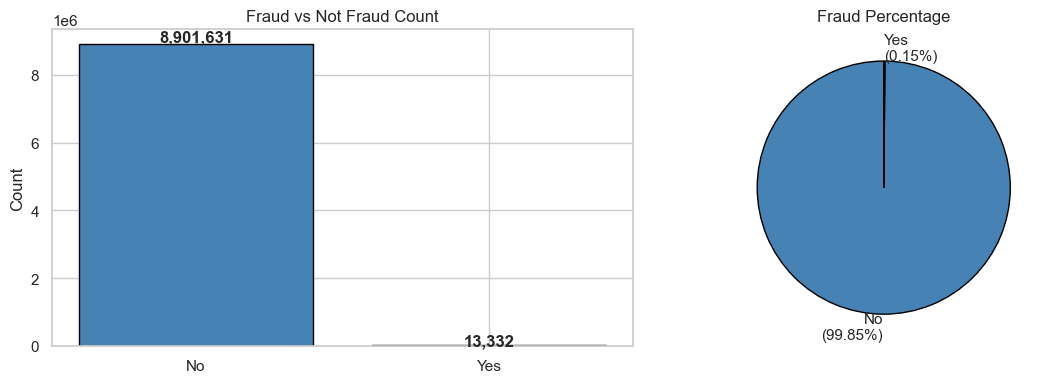

Saved: outputs/class_imbalance.png


In [7]:

# Class imbalance chart
fraud_counts = sample['is_fraud'].value_counts()
total  = fraud_counts.sum()
idx    = fraud_counts.index.tolist()   # actual values e.g. ['No','Yes']
vals   = fraud_counts.values
colors = ['steelblue', 'crimson'][:len(idx)]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bar chart
bars = axes[0].bar(idx, vals, color=colors, edgecolor='black')
axes[0].set_title('Fraud vs Not Fraud Count')
axes[0].set_ylabel('Count')
for bar, v in zip(bars, vals):
    axes[0].text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() * 1.01, f'{v:,}', ha='center', fontweight='bold')

# Pie chart
pie_labels = [f'{l}\n({v/total*100:.2f}%)' for l, v in zip(idx, vals)]
axes[1].pie(vals, labels=pie_labels, colors=colors,
            startangle=90, wedgeprops={'edgecolor': 'black'})
axes[1].set_title('Fraud Percentage')

plt.tight_layout()
plt.savefig(OUT_DIR / 'class_imbalance.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: outputs/class_imbalance.png')


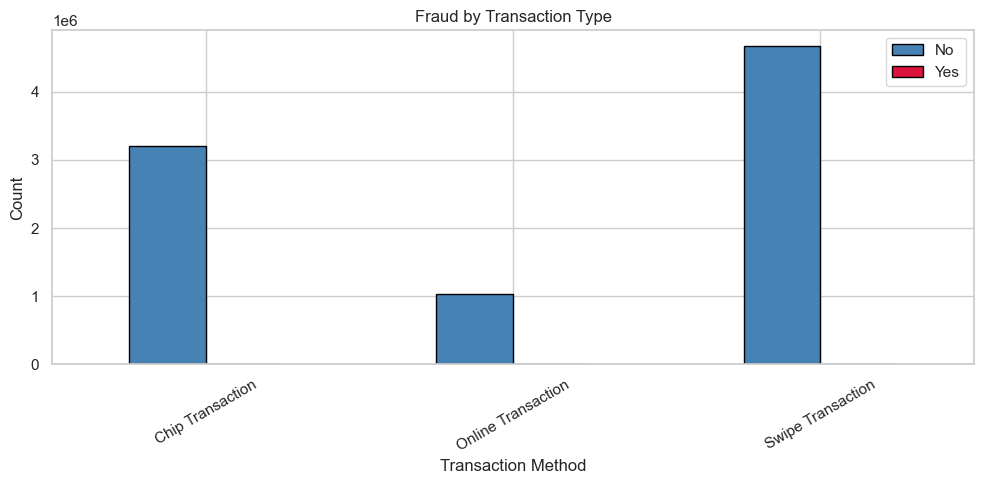

Saved: outputs/fraud_by_chip.png


In [8]:

# Fraud by transaction type
fraud_by_chip = sample.groupby(['use_chip', 'is_fraud']).size().unstack(fill_value=0)
n_cols  = len(fraud_by_chip.columns)
colors  = ['steelblue', 'crimson'][:n_cols]

fraud_by_chip.plot(kind='bar', figsize=(10, 5), color=colors, edgecolor='black')
plt.title('Fraud by Transaction Type')
plt.xlabel('Transaction Method')
plt.ylabel('Count')
plt.xticks(rotation=30)
plt.legend(fraud_by_chip.columns.tolist())
plt.tight_layout()
plt.savefig(OUT_DIR / 'fraud_by_chip.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: outputs/fraud_by_chip.png')


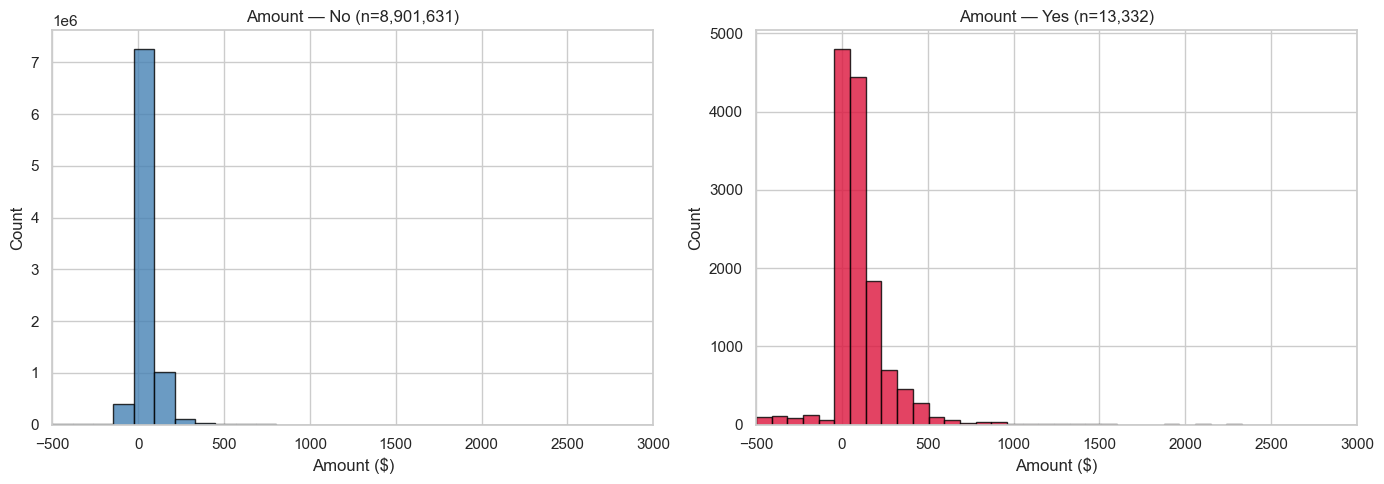

Saved: outputs/amount_distribution.png


In [9]:

# Amount distribution by fraud label
sample['amount_clean']  = sample['amount'].str.replace(r'[$,]', '', regex=True).astype(float)
unique_fraud_vals       = sample['is_fraud'].unique().tolist()
colors                  = ['steelblue', 'crimson']

fig, axes = plt.subplots(1, len(unique_fraud_vals), figsize=(7 * len(unique_fraud_vals), 5))
if len(unique_fraud_vals) == 1:
    axes = [axes]

for ax, val, color in zip(axes, unique_fraud_vals, colors):
    data = sample[sample['is_fraud'] == val]['amount_clean']
    ax.hist(data, bins=60, color=color, edgecolor='black', alpha=0.8)
    ax.set_title(f'Amount — {val} (n={len(data):,})')
    ax.set_xlabel('Amount ($)')
    ax.set_ylabel('Count')
    ax.set_xlim(-500, 3000)

plt.tight_layout()
plt.savefig(OUT_DIR / 'amount_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: outputs/amount_distribution.png')


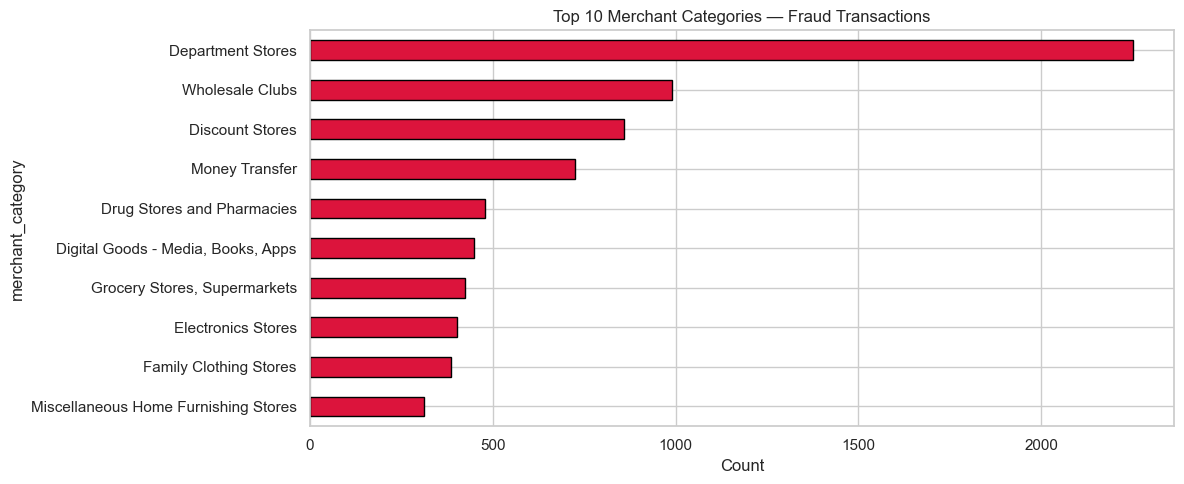

Saved: outputs/top_fraud_categories.png


In [10]:
# Top fraud merchant categories
sample['mcc_str']           = sample['mcc'].astype(str)
sample['merchant_category'] = sample['mcc_str'].map(mcc_codes).fillna('Unknown')

fraud_only = sample[sample['is_fraud'] == 'Yes']
top_cats   = fraud_only['merchant_category'].value_counts().head(10)

plt.figure(figsize=(12, 5))
top_cats.plot(kind='barh', color='crimson', edgecolor='black')
plt.title('Top 10 Merchant Categories — Fraud Transactions')
plt.xlabel('Count')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig(OUT_DIR / 'top_fraud_categories.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: outputs/top_fraud_categories.png')

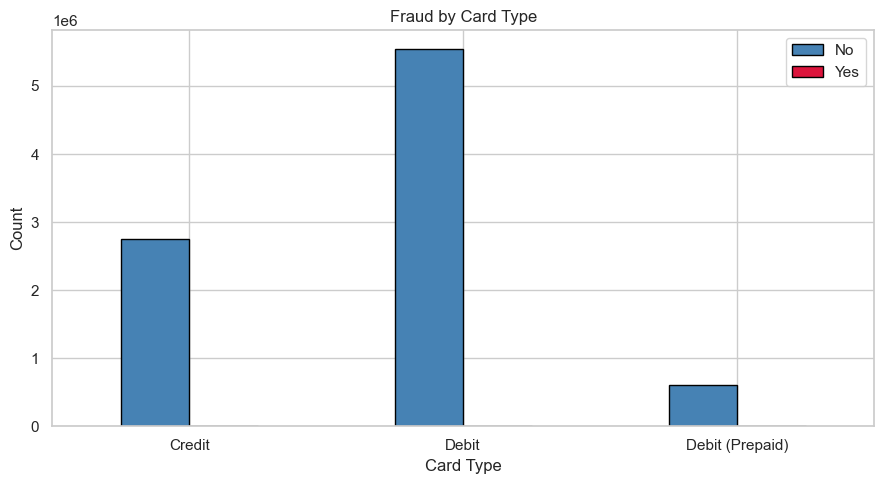

Saved: outputs/fraud_by_card_type.png


In [11]:

# Fraud by card type
cards['id']       = cards['id'].astype(str)
sample['card_id'] = sample['card_id'].astype(str)

sample_cards  = sample.merge(
    cards[['id', 'card_type', 'card_brand', 'has_chip', 'card_on_dark_web']],
    left_on='card_id', right_on='id', how='left', suffixes=('', '_card')
)
fraud_by_card = sample_cards.groupby(['card_type', 'is_fraud']).size().unstack(fill_value=0)
n_cols        = len(fraud_by_card.columns)
colors        = ['steelblue', 'crimson'][:n_cols]

fraud_by_card.plot(kind='bar', figsize=(9, 5), color=colors, edgecolor='black')
plt.title('Fraud by Card Type')
plt.xlabel('Card Type')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.legend(fraud_by_card.columns.tolist())
plt.tight_layout()
plt.savefig(OUT_DIR / 'fraud_by_card_type.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: outputs/fraud_by_card_type.png')


In [12]:
fraud_rows  = (sample['is_fraud'] == 'Yes').sum()
nfraud_rows = (sample['is_fraud'] == 'No').sum()
fraud_rate  = fraud_rows / len(sample) * 100

# amount_clean may not exist if the amount distribution cell was skipped
if 'amount_clean' not in sample.columns:
    sample['amount_clean'] = pd.to_numeric(
        sample['amount'].str.replace(r'[$,]', '', regex=True), errors='coerce'
    )

f_amt  = sample[sample['is_fraud'] == 'Yes']['amount_clean'].mean()
nf_amt = sample[sample['is_fraud'] == 'No']['amount_clean'].mean()

print('=' * 50)
print('EDA SUMMARY')
print('=' * 50)
print(f'Total rows             : {len(sample):,}')
print(f'Fraud count            : {fraud_rows:,}')
print(f'Not fraud count        : {nfraud_rows:,}')
print(f'Fraud rate             : {fraud_rate:.4f}%')
print()
print(f'Avg amount (fraud)     : ${f_amt:.2f}')
print(f'Avg amount (not fraud) : ${nf_amt:.2f}')
print()
print('Charts saved to /outputs/')
print('EDA complete. Ready for preprocessing.')

EDA SUMMARY
Total rows             : 8,914,963
Fraud count            : 13,332
Not fraud count        : 8,901,631
Fraud rate             : 0.1495%

Avg amount (fraud)     : $110.23
Avg amount (not fraud) : $42.85

Charts saved to /outputs/
EDA complete. Ready for preprocessing.
